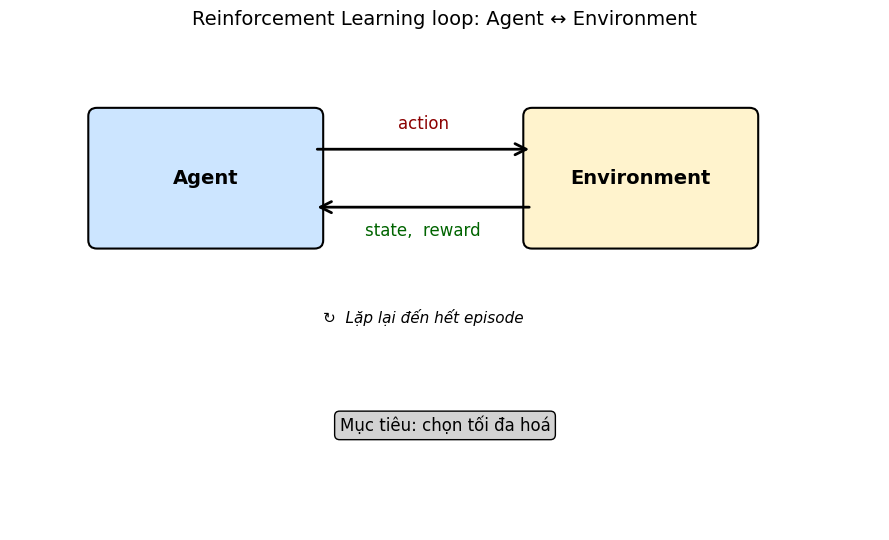

In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.set_xlim(0, 10); ax.set_ylim(0, 6); ax.axis('off')

# Agent box
agent = FancyBboxPatch((1, 3.5), 2.5, 1.5, boxstyle='round,pad=0.1',
                       facecolor='#cce5ff', edgecolor='black', linewidth=1.5)
ax.add_patch(agent)
ax.text(2.25, 4.25, 'Agent', ha='center', va='center', fontsize=14, fontweight='bold')

# Environment box
env = FancyBboxPatch((6, 3.5), 2.5, 1.5, boxstyle='round,pad=0.1',
                     facecolor='#fff3cd', edgecolor='black', linewidth=1.5)
ax.add_patch(env)
ax.text(7.25, 4.25, 'Environment', ha='center', va='center', fontsize=14, fontweight='bold')

# Action arrow (Agent -> Env)
ax.add_patch(FancyArrowPatch((3.5, 4.6), (6, 4.6), arrowstyle='->',
                             mutation_scale=20, color='black', linewidth=2))
ax.text(4.75, 4.85, 'action', ha='center', fontsize=12, color='darkred')

# State + Reward arrow (Env -> Agent)
ax.add_patch(FancyArrowPatch((6, 3.9), (3.5, 3.9), arrowstyle='->',
                             mutation_scale=20, color='black', linewidth=2))
ax.text(4.75, 3.55, 'state,  reward', ha='center', fontsize=12, color='darkgreen')

# Cycle indicator
ax.text(4.75, 2.5, '↻  Lặp lại đến hết episode', ha='center', fontsize=11, style='italic')

# Goal box at bottom
ax.text(5, 1.2, 'Mục tiêu: chọn tối đa hoá',ha='center', fontsize=12, bbox=dict(boxstyle='round', facecolor='lightgray'))

ax.set_title('Reinforcement Learning loop: Agent ↔ Environment', fontsize=14)
plt.tight_layout(); plt.show()

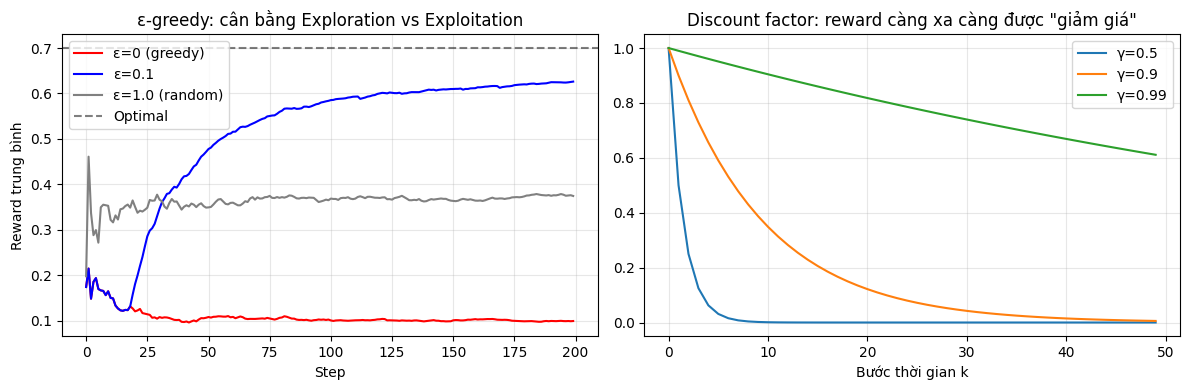

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Minh hoạ ε-greedy — vì sao cần exploration.
np.random.seed(0)
n_arms = 5
true_means = np.array([0.1, 0.3, 0.5, 0.7, 0.4])  # 5 cánh tay
n_steps = 200

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label, eps, color in [('ε=0 (greedy)', 0.0, 'red'),
                          ('ε=0.1', 0.1, 'blue'),
                          ('ε=1.0 (random)', 1.0, 'gray')]:
    np.random.seed(0)
    Q = np.zeros(n_arms); n = np.zeros(n_arms); rewards = []
    for t in range(n_steps):
        if np.random.rand() < eps:
            a = np.random.randint(n_arms)
        else:
            a = int(np.argmax(Q))
        r = np.random.randn() * 0.1 + true_means[a]
        n[a] += 1
        Q[a] += (r - Q[a]) / n[a]
        rewards.append(r)
    cum = np.cumsum(rewards) / np.arange(1, n_steps + 1)
    axes[0].plot(cum, label=label, color=color)

axes[0].axhline(true_means.max(), color='black', linestyle='--', alpha=0.5, label='Optimal')
axes[0].set_xlabel('Step'); axes[0].set_ylabel('Reward trung bình')
axes[0].set_title('ε-greedy: cân bằng Exploration vs Exploitation')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Discount factor
gammas = [0.5, 0.9, 0.99]
ts = np.arange(50)
for g in gammas:
    axes[1].plot(ts, g**ts, label=f'γ={g}')
axes[1].set_xlabel('Bước thời gian k'); axes[1].set_ylabel('')
axes[1].set_title('Discount factor: reward càng xa càng được \"giảm giá\"')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## THỰC HÀNH 1: Q-Learning trên FrozenLake

FrozenLake là môi trường đơn giản trong gym:

*   Lưới 4×4. Agent bắt đầu ở góc trái trên, mục tiêu là góc phải dưới.
*   Có một số ô "hố" — rơi vào là kết thúc episode, reward 0.
*   Đến đích → reward 1.

Hai biến thể: `is_slippery=True` (đi trượt — khó), `False` (đi đúng hướng — dễ). Ta dùng phiên bản dễ trước.

Cài thư viện trước (chỉ chạy 1 lần):

In [5]:
pip install gymnasium

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import random

try:
    import gymnasium as gym
except ImportError:
    print('Chưa cài gymnasium — chạy: pip install gymnasium')
    raise

np.random.seed(42)
random.seed(42)

env = gym.make('FrozenLake-v1', is_slippery=True)
n_states  = env.observation_space.n      # 16
n_actions = env.action_space.n           # 4 (trái, dưới, phải, lên)
print(f'Số state: {n_states}, số action: {n_actions}')

# Bản đồ FrozenLake mặc định:
# S F F F
# F H F H
# F F F H
# H F F G
# S = start, F = frozen (đi được), H = hole, G = goal.

Số state: 16, số action: 4


In [18]:
Q = np.zeros((n_states, n_actions))

# Hyperparams
alpha    = 0.8       # learning rate
gamma    = 0.95      # discount factor
epsilon  = 1.0       # exploration rate (giảm dần)
eps_decay = 0.995
eps_min  = 0.01
n_episodes = 5000 # Increased episodes for slippery environment

rewards_history = []

for ep in range(n_episodes):
    state, _ = env.reset()
    total_reward = 0
    done = False
    while not done:
        # ε-greedy: chọn ngẫu nhiên với xác suất ε.
        if random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = int(np.argmax(Q[state]))

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # Cập nhật Q-table.
        Q[state, action] += alpha * (reward + gamma * np.max(Q[next_state]) - Q[state, action])

        state = next_state
        total_reward += reward

    epsilon = max(eps_min, epsilon * eps_decay)
    rewards_history.append(total_reward)

    if (ep + 1) % 500 == 0: # Print less frequently due to more episodes
        avg = np.mean(rewards_history[-100:])
        print(f'Episode {ep+1:4d}  avg reward last 100: {avg:.2f}  ε = {epsilon:.3f}')

Episode  500  avg reward last 100: 0.18  ε = 0.082
Episode 1000  avg reward last 100: 0.45  ε = 0.010
Episode 1500  avg reward last 100: 0.49  ε = 0.010
Episode 2000  avg reward last 100: 0.53  ε = 0.010
Episode 2500  avg reward last 100: 0.46  ε = 0.010
Episode 3000  avg reward last 100: 0.43  ε = 0.010
Episode 3500  avg reward last 100: 0.41  ε = 0.010
Episode 4000  avg reward last 100: 0.57  ε = 0.010
Episode 4500  avg reward last 100: 0.50  ε = 0.010
Episode 5000  avg reward last 100: 0.55  ε = 0.010


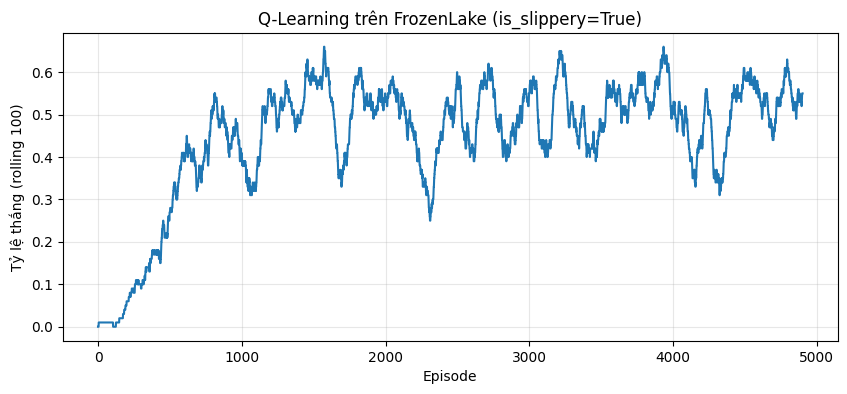

In [19]:
# Vẽ tỷ lệ thành công theo episode (rolling window 100).
rewards_arr = np.array(rewards_history)
rolling = np.convolve(rewards_arr, np.ones(100)/100, mode='valid')

plt.figure(figsize=(10, 4))
plt.plot(rolling)
plt.xlabel('Episode'); plt.ylabel('Tỷ lệ thắng (rolling 100)')
plt.title('Q-Learning trên FrozenLake (is_slippery=True)')
plt.grid(alpha=0.3); plt.show()

In [22]:
# Kiểm tra chính sách đã học bằng cách chạy 100 episode greedy.
wins = 0
for _ in range(100):
    state, _ = env.reset()
    done = False
    while not done:
        action = int(np.argmax(Q[state]))
        state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        if reward > 0: wins += 1
print(f'Tỷ lệ thắng greedy: {wins}/100')

# In bảng Q-table cho 4 ô đầu tiên
print('''\nQ-table (4 hàng đầu — state 0,1,2,3):''')
print('Action: [trái, dưới, phải, lên]')
for s in range(4):
    print(f'State {s}: {Q[s].round(3)}')

Tỷ lệ thắng greedy: 46/100

Q-table (4 hàng đầu — state 0,1,2,3):
Action: [trái, dưới, phải, lên]
State 0: [0.154 0.08  0.346 0.08 ]
State 1: [0.002 0.006 0.    0.185]
State 2: [0.016 0.092 0.008 0.041]
State 3: [0.005 0.002 0.002 0.043]


### Trực quan chính sách
Vẽ mũi tên trên bản đồ 4×4 thể hiện action mà agent chọn ở mỗi state.

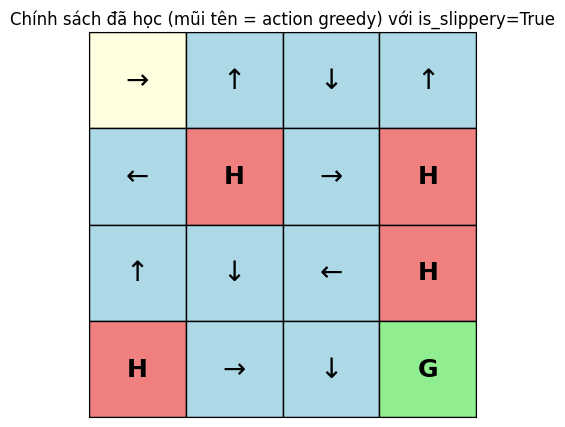

In [21]:
arrows = ['←', '↓', '→', '↑']
lake_map = ['S', 'F', 'F', 'F',
            'F', 'H', 'F', 'H',
            'F', 'F', 'F', 'H',
            'H', 'F', 'F', 'G']

fig, ax = plt.subplots(figsize=(5, 5))
for i in range(4):
    for j in range(4):
        s = i * 4 + j
        cell = lake_map[s]
        if cell in ('S', 'G'):
            color = 'lightgreen' if cell == 'G' else 'lightyellow'
        elif cell == 'H':
            color = 'lightcoral'
        else:
            color = 'lightblue'
        ax.add_patch(plt.Rectangle((j, 3-i), 1, 1, facecolor=color, edgecolor='black'))
        # Only show action for non-hole cells and non-goal cell
        if cell not in ('H', 'G'):
            best_a = int(np.argmax(Q[s]))
            ax.text(j + 0.5, 3-i + 0.5, arrows[best_a], ha='center', va='center', fontsize=20)
        else:
            ax.text(j + 0.5, 3-i + 0.5, cell, ha='center', va='center', fontsize=18, fontweight='bold')
ax.set_xlim(0, 4); ax.set_ylim(0, 4); ax.set_xticks([]); ax.set_yticks([])
ax.set_title('Chính sách đã học (mũi tên = action greedy) với is_slippery=True')
plt.show()

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

env = gym.make('CartPole-v1')
state_dim = env.observation_space.shape[0]   # 4
action_dim = env.action_space.n              # 2
print('state_dim:', state_dim, ' action_dim:', action_dim)

state_dim: 4  action_dim: 2


In [12]:
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden),    nn.ReLU(),
            nn.Linear(hidden, action_dim),
        )
    def forward(self, s):
        return self.net(s)

policy_net = QNetwork(state_dim, action_dim).to(device)
# Target network: a separate copy, updated slowly to stabilize training.
target_net = QNetwork(state_dim, action_dim).to(device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=1e-3)
criterion = nn.MSELoss()

In [23]:
# Replay buffer: stores transitions (s, a, r, s', done) to sample mini-batches.
# Breaks temporal correlation — important for stable training.
replay = deque(maxlen=10000)
batch_size = 64
gamma = 0.99
epsilon = 1.0
eps_decay = 0.995
eps_min = 0.05
target_update_freq = 10   # update target_net every 10 episodes
tau = 0.005               # for soft update

In [24]:
def select_action(state, eps):
    if random.random() < eps:
        return env.action_space.sample()
    with torch.no_grad():
        s = torch.FloatTensor(state).unsqueeze(0).to(device)
        return int(policy_net(s).argmax(dim=1).item())

def train_step():
    if len(replay) < batch_size:
        return
    batch = random.sample(replay, batch_size)
    states, actions, rewards, next_states, dones = zip(*batch)
    states      = torch.FloatTensor(np.array(states)).to(device)
    actions     = torch.LongTensor(actions).unsqueeze(1).to(device)
    rewards     = torch.FloatTensor(rewards).to(device)
    next_states = torch.FloatTensor(np.array(next_states)).to(device)
    dones       = torch.FloatTensor(dones).to(device)

    # Current Q-value with selected action (from policy_net)
    q_pred = policy_net(states).gather(1, actions).squeeze(1)

    # Double DQN: Use policy_net to select the action and target_net to evaluate it
    with torch.no_grad():
        # Select action using policy_net
        next_actions = policy_net(next_states).argmax(1, keepdim=True)
        # Evaluate selected action using target_net
        q_next = target_net(next_states).gather(1, next_actions).squeeze(1)
        q_target = rewards + gamma * q_next * (1 - dones)

    loss = criterion(q_pred, q_target)
    optimizer.zero_grad(); loss.backward()
    # Clip gradients to prevent exploding gradients.
    torch.nn.utils.clip_grad_norm_(policy_net.parameters(), 10.0)
    optimizer.step()
    return loss.item()

In [28]:
# Re-initialize CartPole environment to ensure correct state dimensions
env = gym.make('CartPole-v1')
replay.clear()

n_episodes = 1000
ep_rewards = []
epsilon = 1.0

for ep in range(n_episodes):
    state, _ = env.reset(seed=ep)
    total = 0
    done = False
    while not done:
        action = select_action(state, epsilon)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        replay.append((np.array(state, dtype=np.float32), action, reward, np.array(next_state, dtype=np.float32), float(done)))

        train_step()
        state = next_state
        total += reward

        # Soft update for target network
        for target_param, policy_param in zip(target_net.parameters(), policy_net.parameters()):
            target_param.data.copy_(tau * policy_param.data + (1.0 - tau) * target_param.data)

    epsilon = max(eps_min, epsilon * eps_decay)
    ep_rewards.append(total)

    if (ep + 1) % 50 == 0:
        avg = np.mean(ep_rewards[-50:])
        print(f"Ep {ep+1:4d}  avg reward last 50: {avg:6.2f}  ̵ = {epsilon:.3f}")
        if avg >= 475:
            print("Solved!")
            break

Ep   50  avg reward last 50:  22.00  ̵ = 0.778
Ep  100  avg reward last 50:  25.82  ̵ = 0.606
Ep  150  avg reward last 50:  31.54  ̵ = 0.471
Ep  200  avg reward last 50:  96.24  ̵ = 0.367
Ep  250  avg reward last 50:  91.54  ̵ = 0.286
Ep  300  avg reward last 50: 124.82  ̵ = 0.222
Ep  350  avg reward last 50:  93.64  ̵ = 0.173
Ep  400  avg reward last 50: 119.50  ̵ = 0.135
Ep  450  avg reward last 50: 135.80  ̵ = 0.105
Ep  500  avg reward last 50: 175.82  ̵ = 0.082
Ep  550  avg reward last 50:  96.16  ̵ = 0.063
Ep  600  avg reward last 50: 241.72  ̵ = 0.050
Ep  650  avg reward last 50: 208.46  ̵ = 0.050
Ep  700  avg reward last 50: 167.94  ̵ = 0.050
Ep  750  avg reward last 50: 163.22  ̵ = 0.050
Ep  800  avg reward last 50: 228.64  ̵ = 0.050
Ep  850  avg reward last 50: 148.46  ̵ = 0.050
Ep  900  avg reward last 50: 150.36  ̵ = 0.050
Ep  950  avg reward last 50: 232.44  ̵ = 0.050
Ep 1000  avg reward last 50: 203.72  ̵ = 0.050


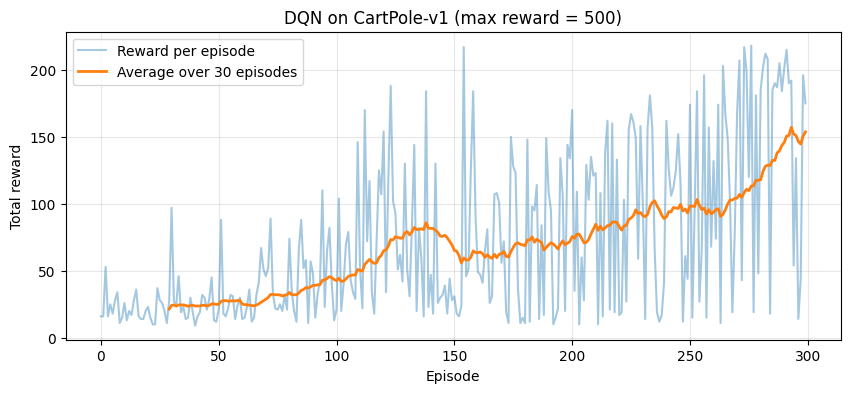

In [16]:
plt.figure(figsize=(10, 4))
plt.plot(ep_rewards, alpha=0.4, label='Reward per episode')
if len(ep_rewards) >= 30:
    rolling = np.convolve(ep_rewards, np.ones(30)/30, mode='valid')
    plt.plot(range(29, len(ep_rewards)), rolling, label='Average over 30 episodes', linewidth=2)
plt.xlabel('Episode'); plt.ylabel('Total reward')
plt.title('DQN on CartPole-v1 (max reward = 500)')
plt.legend(); plt.grid(alpha=0.3); plt.show()

## THỰC HÀNH 3: Visualizing the Agent

Chúng ta sẽ quay lại một episode sử dụng chính sách đã huấn luyện và lưu thành file MP4.

In [31]:
!pip install moviepy
import glob
import io
import base64
from IPython.display import HTML
from gymnasium.wrappers import RecordVideo

def record_video(env_id, model, video_folder):
    # Create a triggered environment for recording
    trigger_env = gym.make(env_id, render_mode='rgb_array')
    # RecordVideo automatically saves the episode
    test_env = RecordVideo(trigger_env, video_folder=video_folder, episode_trigger=lambda x: True, name_prefix='dqn_result')

    state, _ = test_env.reset(seed=42)
    done = False
    total_reward = 0

    while not done:
        with torch.no_grad():
            s = torch.FloatTensor(state).unsqueeze(0).to(device)
            action = int(model(s).argmax(dim=1).item())

        next_state, reward, terminated, truncated, _ = test_env.step(action)
        state = next_state
        total_reward += reward
        done = terminated or truncated

    test_env.close()
    print(f'Finished recording. Total reward: {total_reward}')

# Record CartPole video to 'videos' folder
record_video('CartPole-v1', policy_net, './videos')

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"


Finished recording. Total reward: 500.0


## THỰC HÀNH 4: Câu hỏi lý thuyết (DQN 2013)

**Câu hỏi:**
1. Tại sao cần Replay Buffer?
2. Mục tiêu của Target Network là gì?
3. Double DQN giải quyết vấn đề gì của DQN truyền thống?

**Trả lời:**
1. **Replay Buffer:** Giúp phá vỡ sự tương quan giữa các mẫu dữ liệu liên tiếp (temporal correlation). Bằng cách lưu lại các transition và lấy mẫu ngẫu nhiên (mini-batch), agent học được từ nhiều trải nghiệm khác nhau một cách ổn định hơn, tương tự như việc học có giám sát (IID data).
2. **Target Network:** Giảm bớt sự mất ổn định khi huấn luyện. Nếu dùng cùng một mạng để dự đoán Q(s,a) và tính toán mục tiêu (target Q), mục tiêu sẽ liên tục thay đổi (chasing your own tail). Target Network giữ cố định các trọng số trong một khoảng thời gian để tạo ra một 'mốc' ổn định cho việc cập nhật.
3. **Double DQN:** Giải quyết vấn đề **overestimation bias** (ước lượng quá cao giá trị Q). DQN truyền thống thường chọn action có giá trị Q lớn nhất (max Q), dẫn đến việc cộng dồn các sai số dương. Double DQN tách biệt việc chọn hành động (dùng policy net) và đánh giá hành động đó (dùng target net).